1. Imports and Configuration

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F 
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.animation as animation
from IPython.display import HTML
from sklearn.manifold import TSNE
import hashlib

username = "muskan.sharma"
seed = int(hashlib.sha256(username.encode()).hexdigest(), 16) % (2**32)

LATENT_DIM = 20  
H_DIM = 512      
BETA = 1.0     
BATCH_SIZE = 128
EPOCHS = 20
LEARNING_RATE = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
INPUT_DIM = 28 * 28

print(f"Using device: {DEVICE}")

Using device: cpu


### 4.2 Dataset Preparation 

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(), 
])

full_train_dataset = datasets.FashionMNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST('./data', train=False, download=True, transform=transform)

train_size = 50000
val_size = len(full_train_dataset) - train_size


train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# 4. Create the DataLoaders
BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Dataset Loaded and Split:")
print(f"  Training set size: {len(train_dataset)} ")
print(f"  Validation set size: {len(val_dataset)} ")
print(f"  Test set size: {len(test_dataset)} ")
print(f"Batch Size: {BATCH_SIZE}")

Dataset Loaded and Split:
  Training set size: 50000 
  Validation set size: 10000 
  Test set size: 10000 
Batch Size: 128


4.3 Model Architecture

In [3]:
class VAE(nn.Module):

    def __init__(self, input_dim, h_dim, latent_dim):
        super(VAE, self).__init__()

        # Encoder Layers
        self.fc1 = nn.Linear(input_dim, h_dim)
        self.fc_mu = nn.Linear(h_dim, latent_dim)
        self.fc_log_var = nn.Linear(h_dim, latent_dim)

        # Decoder Layers
        self.fc3 = nn.Linear(latent_dim, h_dim)
        self.fc4 = nn.Linear(h_dim, input_dim)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        mu = self.fc_mu(h)
        log_var = self.fc_log_var(h)
        return mu, log_var
    
    def decode(self, z):
        h = F.relu(self.fc3(z))
        x_hat = F.sigmoid(self.fc4(h))
        return x_hat
    
    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        epsilon = torch.randn_like(std)
        z = mu + epsilon * std
        return z
    
    def forward(self, x):
        
        batch_size = x.shape[0]
        x = x.view(batch_size, -1)
        
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        x_hat = self.decode(z)
        
        return x_hat, mu, log_var

4.4 Loss Function

In [4]:
def loss_function(x_hat, x, mu, logvar, beta):

    BCE = F.binary_cross_entropy(x_hat, x.view(-1, INPUT_DIM), reduction='sum')

    # KL Divergence: D_KL(q(z|x) || p(z))
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    total_loss = BCE + beta * KLD
    
    batch_size = x.size(0)
    return total_loss / batch_size, BCE / batch_size, KLD / batch_size

Dataset, Model Initialization, and Training Function

Model initialized with LD: 20, HD: 512

--- Starting Training (Standard VAE, Beta=1.0) ---


Epoch 1 Training:   0%|          | 0/391 [00:00<?, ?it/s]

====> Epoch: 1 Average Loss: 287.1375 | BCE: 273.2585 | KL: 13.8790


Epoch 2 Training:   0%|          | 0/391 [00:00<?, ?it/s]

====> Epoch: 2 Average Loss: 256.6496 | BCE: 241.4932 | KL: 15.1564


...

====> Epoch: 18 Average Loss: 240.5394 | BCE: 224.4376 | KL: 16.1019


Epoch 19 Training:   0%|          | 0/391 [00:00<?, ?it/s]

====> Epoch: 19 Average Loss: 240.3781 | BCE: 224.2565 | KL: 16.1216


Epoch 20 Training:   0%|          | 0/391 [00:00<?, ?it/s]

====> Epoch: 20 Average Loss: 240.2191 | BCE: 224.1233 | KL: 16.0958


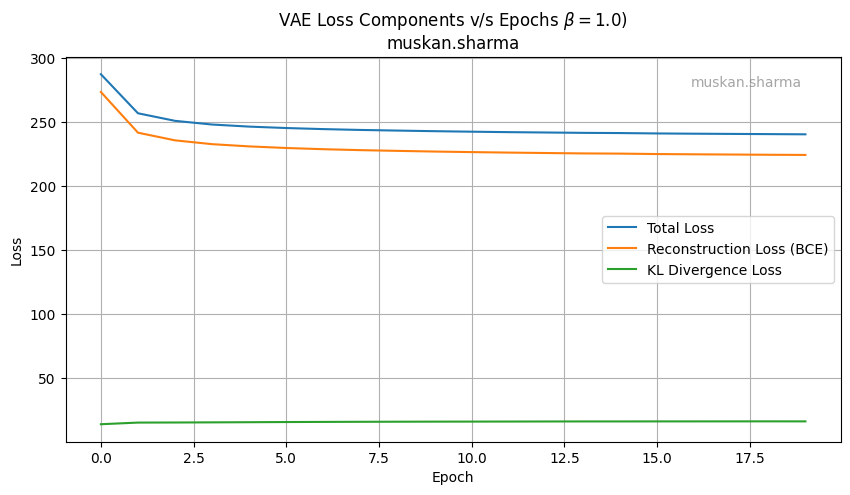

In [5]:
model = VAE(INPUT_DIM, H_DIM, LATENT_DIM).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
print(f"Model initialized with LD: {LATENT_DIM}, HD: {H_DIM}")


def train(epoch, model, optimizer, loader, beta):
    model.train()
    total_loss, bce_loss, kl_loss = 0, 0, 0
    
    for _, (data, _) in enumerate(tqdm(loader, desc=f"Epoch {epoch} Training")):
        data = data.to(DEVICE)
        optimizer.zero_grad()
        
        x_hat, mu, log_var = model(data)
        
        loss_t, bce_l, kl_l = loss_function(x_hat, data, mu, log_var, beta=beta)
        
        loss_t.backward()
        optimizer.step()
        
        total_loss += loss_t.item()
        bce_loss += bce_l.item()
        kl_loss += kl_l.item()
        
    avg_loss = total_loss / len(loader)
    avg_bce = bce_loss / len(loader)
    avg_kl = kl_loss / len(loader)

    print(f'====> Epoch: {epoch} Average Loss: {avg_loss:.4f} | BCE: {avg_bce:.4f} | KL: {avg_kl:.4f}')
    return avg_loss, avg_bce, avg_kl

loss_history = {'total': [], 'bce': [], 'kl': []}

print("\n--- Starting Training (Standard VAE, Beta=1.0) ---")
for epoch in range(1, EPOCHS + 1):
    total_l, bce_l, kl_l = train(epoch, model, optimizer, train_loader, BETA)
    loss_history['total'].append(total_l)
    loss_history['bce'].append(bce_l)
    loss_history['kl'].append(kl_l)

# Plotting the loss components over epochs
plt.figure(figsize=(10, 5))
plt.plot(loss_history['total'], label='Total Loss')
plt.plot(loss_history['bce'], label='Reconstruction Loss (BCE)')
plt.plot(loss_history['kl'], label='KL Divergence Loss')
plt.title(f'VAE Loss Components v/s Epochs $\\beta={BETA}$) \n{username}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.text(0.95, 0.95, f"{username}", ha='right', va='top', 
         transform=plt.gca().transAxes, fontsize=10, color='gray', alpha=0.7)
plt.show()

4.6 Experimental Analysis

4.7 Evaluation and Visualization

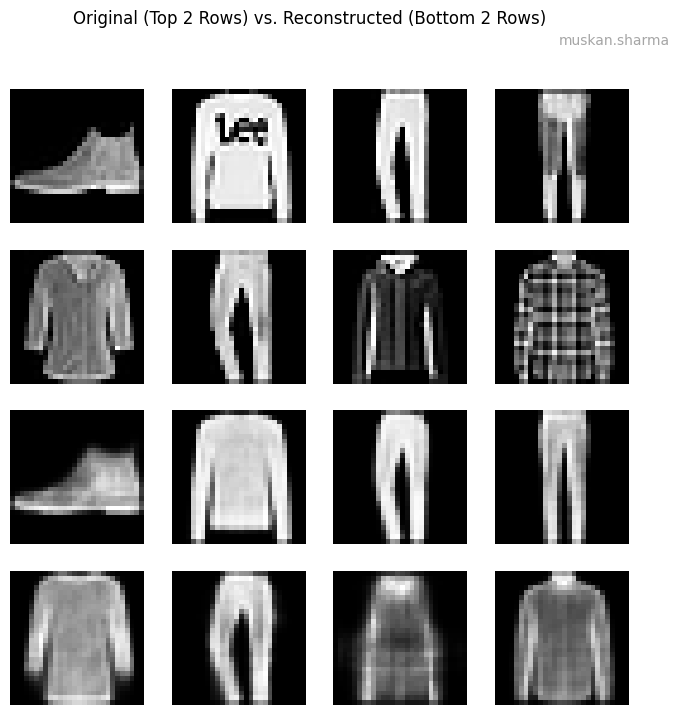

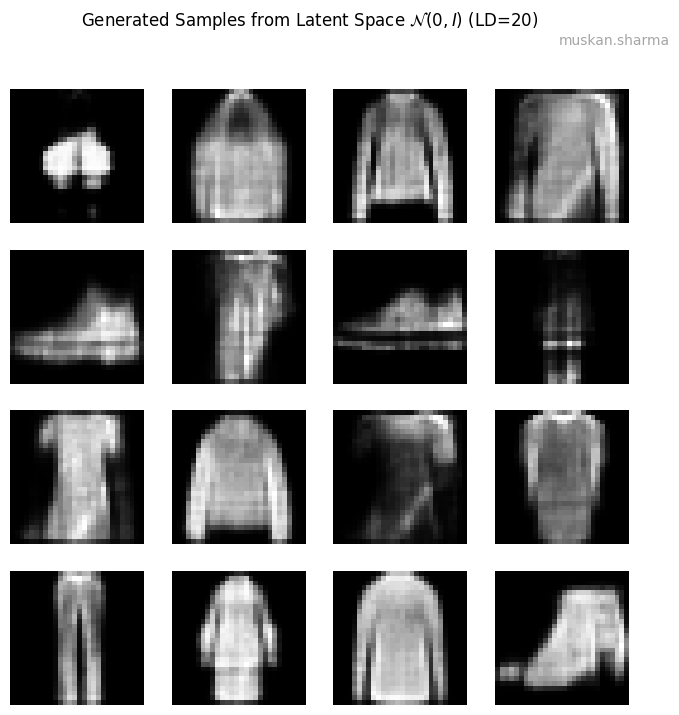

In [6]:
def visualize_reconstruction(model, test_loader):
    model.eval()
    with torch.no_grad():
        data, _ = next(iter(test_loader))
        data = data.to(DEVICE)
        
        reconstruction, _, _ = model(data[:8]) 
        
        original = data[:8].view(-1, 1, 28, 28).cpu()
        reconstruction = reconstruction.view(-1, 1, 28, 28).cpu()
        
        comparison = torch.cat([original, reconstruction], dim=0)
        
        fig, axes = plt.subplots(4, 4, figsize=(8, 8))
        fig.suptitle(f'Original (Top 2 Rows) vs. Reconstructed (Bottom 2 Rows)')
        
        for i in range(16):
            ax = axes[i // 4, i % 4]
            
            if i < 8:
                 ax.imshow(comparison[i].squeeze(), cmap='gray')
            else:
                 ax.imshow(comparison[i].squeeze(), cmap='gray')
            ax.axis('off')
        
        fig.text(0.95, 0.95, f"{username}", ha='right', va='top', 
                 transform=fig.transFigure, fontsize=10, color='gray', alpha=0.7)
        plt.show()

def visualize_generation(model, num_samples=16):
    model.eval()
    with torch.no_grad():
        # Generate new samples by sampling from N(0, I)
        sample_z = torch.randn(num_samples, LATENT_DIM).to(DEVICE)
        
        # Use the explicit decode method
        generated_samples = model.decode(sample_z)
        generated_samples = generated_samples.view(-1, 1, 28, 28).cpu()

        fig, axes = plt.subplots(4, 4, figsize=(8, 8))
        fig.suptitle(f'Generated Samples from Latent Space $\\mathcal{{N}}(0,I)$ (LD={LATENT_DIM})')
        
        for i in range(num_samples):
            ax = axes[i // 4, i % 4]
            ax.imshow(generated_samples[i].squeeze(), cmap='gray')
            ax.axis('off')
            
        fig.text(0.95, 0.95, f"{username}", ha='right', va='top', 
                 transform=fig.transFigure, fontsize=10, color='gray', alpha=0.7)
        plt.show()

visualize_reconstruction(model, test_loader)
visualize_generation(model, num_samples=16)